# Ying Zhu Personal EDA and Predictive Modeling Analysis

## DATA 245 Machine Learning Group 5

**Research question**: Can building characteristics and energy-use indicators predict ENERGY STAR Score?        

This notebook continues from the shared-cleaned dataset and focuses on three stages

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import RandomizedSearchCV

In [6]:
file_path = "NYC_Building_Energy_and_Water_Data_Disclosure_shared_cleaned.csv"
df1 = pd.read_csv(file_path, low_memory=False)

In [7]:
print("Shape:", df1.shape)
print("Columns:", len(df1.columns))

Shape: (103259, 265)
Columns: 265


In [8]:
target = "ENERGY STAR Score"

building_features = [
    "Year Built",
    "Property GFA - Self-Reported (ft²)",
    "Number of Buildings",
    "Occupancy",
    "Primary Property Type - Self Selected",
    "Largest Property Use Type",
    "Largest Property Use Type - Gross Floor Area (ft²)"
]

energy_features = [
    "Electricity Use - Grid Purchase (kBtu)",
    "Natural Gas Use (kBtu)",
    "District Steam Use (kBtu)",
    "District Hot Water Use (kBtu)",
    "Annual Maximum Demand (kW)"
]

selected_features = [c for c in building_features + energy_features if c in df1.columns]

print("Target:", target)
print("Selected features:")
for col in selected_features:
    print("-", col)

Target: ENERGY STAR Score
Selected features:
- Year Built
- Property GFA - Self-Reported (ft²)
- Number of Buildings
- Occupancy
- Primary Property Type - Self Selected
- Largest Property Use Type
- Largest Property Use Type - Gross Floor Area (ft²)
- Electricity Use - Grid Purchase (kBtu)
- Natural Gas Use (kBtu)
- District Steam Use (kBtu)
- District Hot Water Use (kBtu)
- Annual Maximum Demand (kW)


The selected features are intended for preliminary exploratory data analysis. They will be further refined based on missingness, redundancy, and transformation needs before baseline modeling.

## 1. Personal EDA

In [11]:
cols_for_personal_eda = [target] + selected_features
df2 = df1[cols_for_personal_eda].copy()

numeric_features = [
    target,
    "Year Built",
    "Property GFA - Self-Reported (ft²)",
    "Number of Buildings",
    "Occupancy",
    "Largest Property Use Type - Gross Floor Area (ft²)",
    "Electricity Use - Grid Purchase (kBtu)",
    "Natural Gas Use (kBtu)",
    "District Steam Use (kBtu)",
    "District Hot Water Use (kBtu)",
    "Annual Maximum Demand (kW)"
]

numeric_features = [c for c in numeric_features if c in df2.columns]

for col in numeric_features:
    df2[col] = pd.to_numeric(
        df2[col].astype(str).str.replace(",", "", regex=False),
        errors="coerce"
    )

print("Shape of personal EDA data:", df2.shape)
df2.head()

Shape of personal EDA data: (103259, 13)


,ENERGY STAR Score,Year Built,Property GFA - Self-Reported (ft²),Number of Buildings,Occupancy,Primary Property Type - Self Selected,Largest Property Use Type,Largest Property Use Type - Gross Floor Area (ft²),Electricity Use - Grid Purchase (kBtu),Natural Gas Use (kBtu),District Steam Use (kBtu),District Hot Water Use (kBtu),Annual Maximum Demand (kW)
0,96.0,1930,51749.0,1,50,Non-Refrigerated Warehouse,Non-Refrigerated Warehouse,51749.0,70973.0,449200.0,NaN,NaN,NaN
1,61.0,1960,52941.0,1,75,Multifamily Housing,Multifamily Housing,52941.0,1642970.2,1453700.0,NaN,NaN,NaN
2,NaN,1941,35196.0,1,50,Mixed Use Property,Office,17598.0,1395451.2,849365.4,NaN,NaN,NaN
3,64.0,1898,107234.0,1,100,Multifamily Housing,Multifamily Housing,92898.0,2191128.4,5122899.9,NaN,NaN,NaN
4,98.0,1911,75191.0,1,80,Medical Office,Medical Office,71431.0,3711191.8,111000.0,NaN,NaN,NaN


In [12]:
print("Non-missing target count:", df2[target].notna().sum())
print("Missing target count:", df2[target].isna().sum())
print("\nTarget summary:")
print(df2[target].describe())

Non-missing target count: 73377
Missing target count: 29882

Target summary:
count    73377.000000
mean        62.414748
std         29.084765
min          1.000000
25%         42.000000
50%         68.000000
75%         87.000000
max        100.000000
Name: ENERGY STAR Score, dtype: float64


In [13]:
df_model = df2.dropna(subset=[target]).copy()
print("Shape after dropping missing target:", df_model.shape)

Shape after dropping missing target: (73377, 13)


In [14]:
missing_summary = pd.DataFrame({
    "missing_count": df_model[selected_features].isna().sum(),
    "missing_rate": df_model[selected_features].isna().mean()
}).sort_values("missing_rate", ascending=False)

missing_summary

,missing_count,missing_rate
District Hot Water Use (kBtu),73365,0.999836
District Steam Use (kBtu),70092,0.955231
Annual Maximum Demand (kW),68299,0.930796
Natural Gas Use (kBtu),3539,0.048230
Electricity Use - Grid Purchase (kBtu),1039,0.014160
Year Built,0,0.000000
Property GFA - Self-Reported (ft²),0,0.000000
Number of Buildings,0,0.000000
Occupancy,0,0.000000
Primary Property Type - Self Selected,0,0.000000


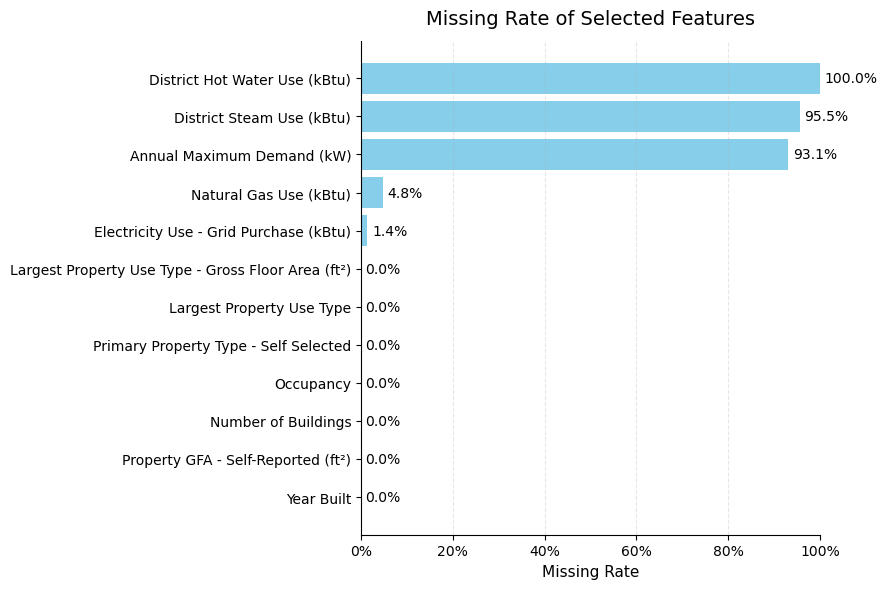

In [15]:
plot_df = missing_summary["missing_rate"].sort_values()

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.barh(plot_df.index, plot_df.values, color="skyblue")

ax.set_title("Missing Rate of Selected Features", fontsize=14, pad=12)
ax.set_xlabel("Missing Rate", fontsize=11)
ax.set_ylabel("")
ax.set_xlim(0, 1)

ax.xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")

ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.grid(False, axis="y")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{width:.1%}",
            va="center",
            fontsize=10)

plt.tight_layout()
plt.show()

In [16]:
high_missing_features = [
    "District Hot Water Use (kBtu)",
    "District Steam Use (kBtu)",
    "Annual Maximum Demand (kW)"
]
df_model = df_model.drop(columns=high_missing_features, errors="ignore")

Because missing values in `Electricity Use - Grid Purchase (kBtu)` and `Natural Gas Use (kBtu)` may reflect non-use or different reporting patterns rather than random omission, missingness indicators are added for both variables before imputation.

In [18]:
df_model["Electricity_missing"] = df_model["Electricity Use - Grid Purchase (kBtu)"].isna().astype(int)
df_model["NaturalGas_missing"] = df_model["Natural Gas Use (kBtu)"].isna().astype(int)

group_col = "Primary Property Type - Self Selected"

# Electricity: group median, then fallback to global median
elec_group_median = df_model.groupby(group_col)["Electricity Use - Grid Purchase (kBtu)"].transform("median")
elec_global_median = df_model["Electricity Use - Grid Purchase (kBtu)"].median()

df_model["Electricity Use - Grid Purchase (kBtu)"] = (
    df_model["Electricity Use - Grid Purchase (kBtu)"]
    .fillna(elec_group_median)
    .fillna(elec_global_median)
)

# Natural gas: option 1 = group median, then fallback
gas_group_median = df_model.groupby(group_col)["Natural Gas Use (kBtu)"].transform("median")
gas_global_median = df_model["Natural Gas Use (kBtu)"].median()

df_model["Natural Gas Use (kBtu)"] = (
    df_model["Natural Gas Use (kBtu)"]
    .fillna(gas_group_median)
    .fillna(gas_global_median)
)
df_model.head(10)

,ENERGY STAR Score,Year Built,Property GFA - Self-Reported (ft²),Number of Buildings,Occupancy,Primary Property Type - Self Selected,Largest Property Use Type,Largest Property Use Type - Gross Floor Area (ft²),Electricity Use - Grid Purchase (kBtu),Natural Gas Use (kBtu),Electricity_missing,NaturalGas_missing
0,96.0,1930,51749.0,1,50,Non-Refrigerated Warehouse,Non-Refrigerated Warehouse,51749.0,70973.0,449200.0,0,0
1,61.0,1960,52941.0,1,75,Multifamily Housing,Multifamily Housing,52941.0,1642970.2,1453700.0,0,0
3,64.0,1898,107234.0,1,100,Multifamily Housing,Multifamily Housing,92898.0,2191128.4,5122899.9,0,0
4,98.0,1911,75191.0,1,80,Medical Office,Medical Office,71431.0,3711191.8,111000.0,0,0
5,61.0,1935,68400.0,1,80,Multifamily Housing,Multifamily Housing,68400.0,703117.6,5199600.0,0,0
6,83.0,1984,89902.0,1,80,Office,Office,89902.0,1579179.3,3297099.7,0,0
7,58.0,1986,63240.0,1,100,Non-Refrigerated Warehouse,Non-Refrigerated Warehouse,63240.0,860677.0,1099100.0,0,0
8,16.0,1937,82576.0,1,100,Multifamily Housing,Multifamily Housing,82576.0,1135718.3,8852599.8,0,0
9,71.0,1933,136000.0,1,100,Multifamily Housing,Multifamily Housing,136000.0,1596587.4,8681600.0,0,0
10,37.0,1942,127200.0,1,100,Multifamily Housing,Multifamily Housing,127200.0,1773356.3,10725000.1,0,0


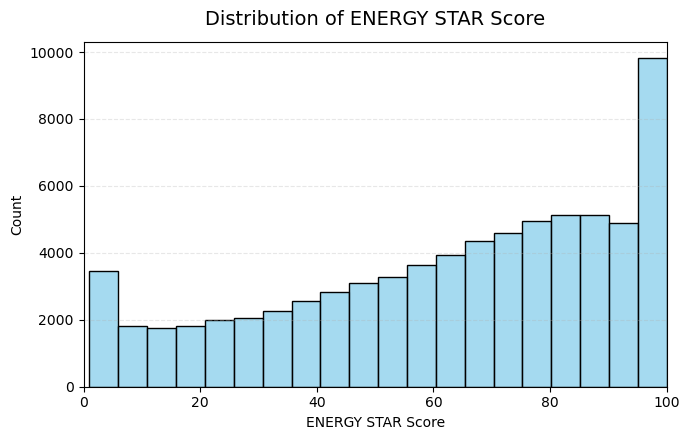

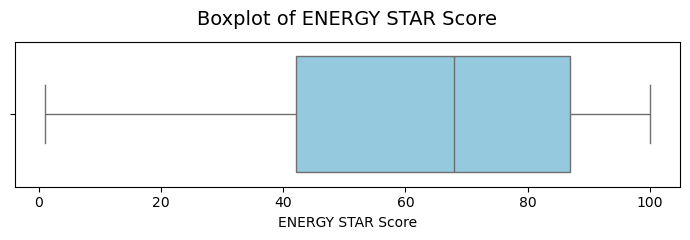

In [19]:
plt.figure(figsize=(7, 4.5))
sns.histplot(df_model[target].dropna(), bins=20, color="skyblue")

plt.title("Distribution of ENERGY STAR Score", fontsize=14, pad=12)
plt.xlabel("ENERGY STAR Score")
plt.ylabel("Count")
plt.xlim(0, 100)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 2.5))
sns.boxplot(x=df_model[target].dropna(), color="skyblue")
plt.title("Boxplot of ENERGY STAR Score", fontsize=14, pad=12)
plt.xlabel("ENERGY STAR Score")
plt.tight_layout()
plt.show()

The ENERGY STAR scores are well distributed across the 1–100 range, providing enough variance for a solid regression model. The distribution is visibly skewed toward higher scores, with far fewer buildings at the low end. We also see a significant cluster at the 100 mark, pointing to a ceiling effect among top-tier performers. Because the median sits above the mean, it’s clear that the lower scoring outliers are dragging the average down. While the variable is a good candidate for modeling, the density of observations at the maximum score might make it tricky for the model to differentiate between the absolute best-performing buildings.

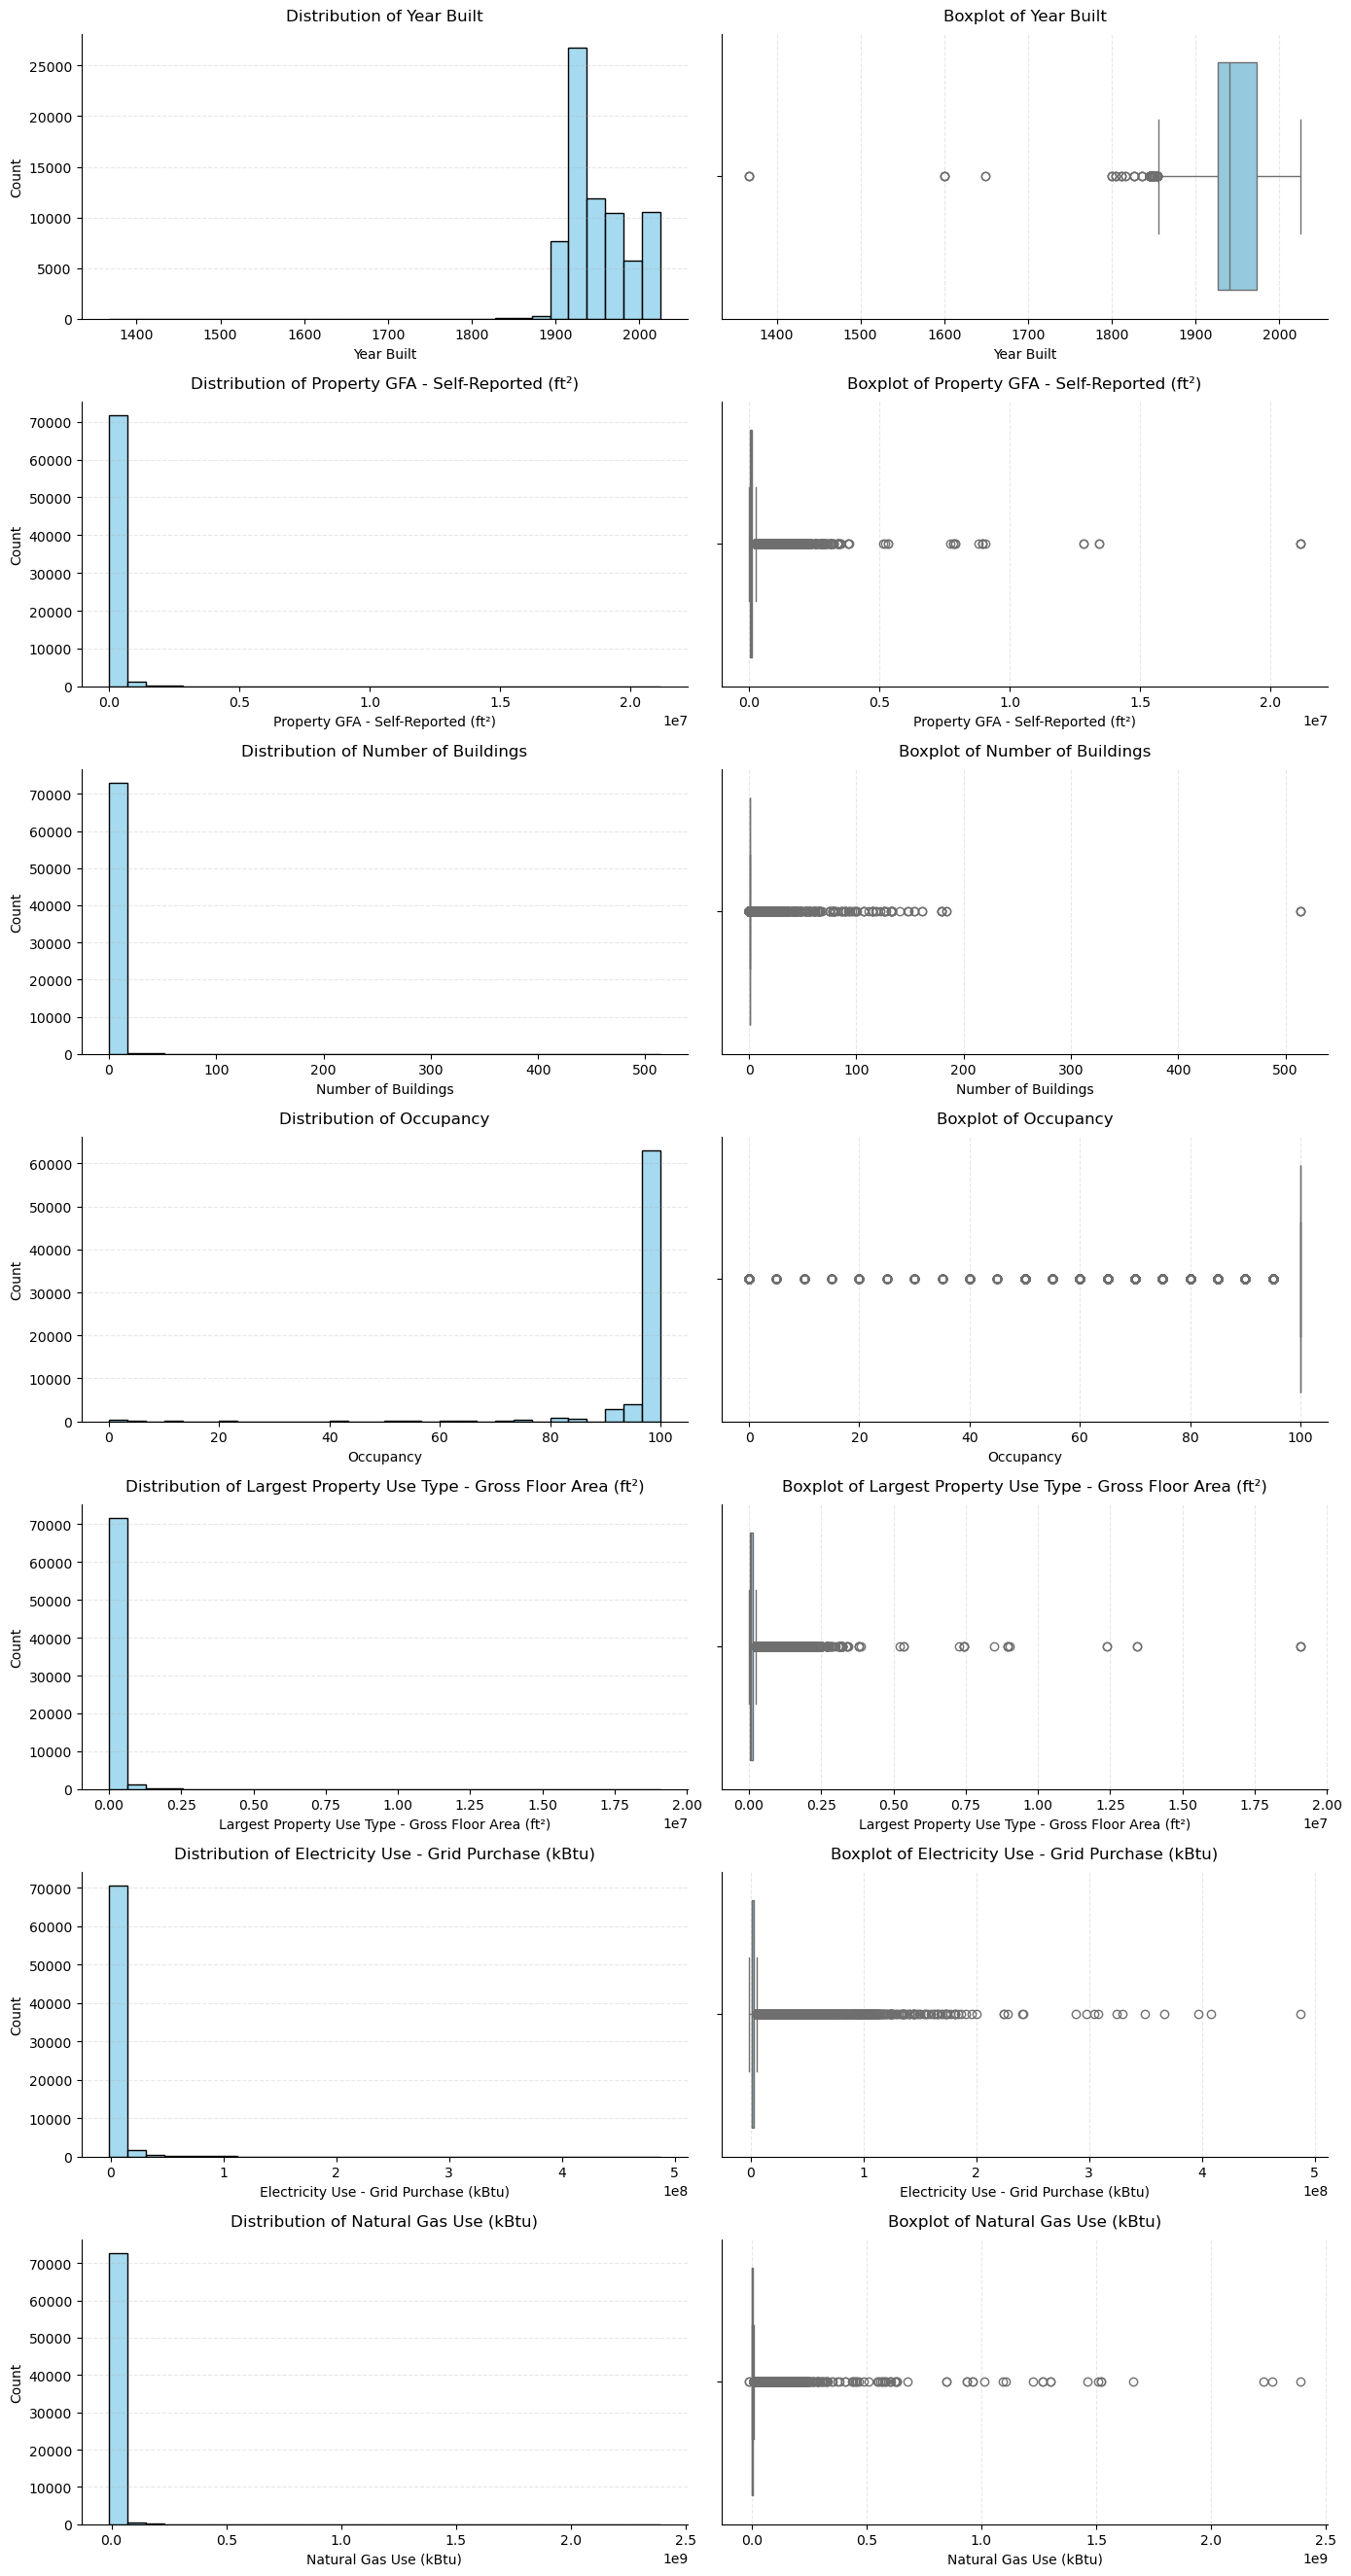

In [21]:
numeric_features_after = [
    "Year Built",
    "Property GFA - Self-Reported (ft²)",
    "Number of Buildings",
    "Occupancy",
    "Largest Property Use Type - Gross Floor Area (ft²)",
    "Electricity Use - Grid Purchase (kBtu)",
    "Natural Gas Use (kBtu)"
]

numeric_features_after = [col for col in numeric_features_after if col in df_model.columns]

n_rows = len(numeric_features_after)

fig, axes = plt.subplots(n_rows, 2, figsize=(14, 3.8 * n_rows))

# in case there is only one feature
if n_rows == 1:
    axes = [axes]

for i, col in enumerate(numeric_features_after):
    data = df_model[col].dropna()

    # left: distribution
    sns.histplot(data, bins=30, color="skyblue", ax=axes[i][0])
    axes[i][0].set_title(f"Distribution of {col}", fontsize=12, pad=10)
    axes[i][0].set_xlabel(col)
    axes[i][0].set_ylabel("Count")
    axes[i][0].grid(axis="y", linestyle="--", alpha=0.3)
    axes[i][0].spines["top"].set_visible(False)
    axes[i][0].spines["right"].set_visible(False)

    # right: boxplot
    sns.boxplot(x=data, color="skyblue", ax=axes[i][1])
    axes[i][1].set_title(f"Boxplot of {col}", fontsize=12, pad=10)
    axes[i][1].set_xlabel(col)
    axes[i][1].set_ylabel("")
    axes[i][1].grid(axis="x", linestyle="--", alpha=0.3)
    axes[i][1].spines["top"].set_visible(False)
    axes[i][1].spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

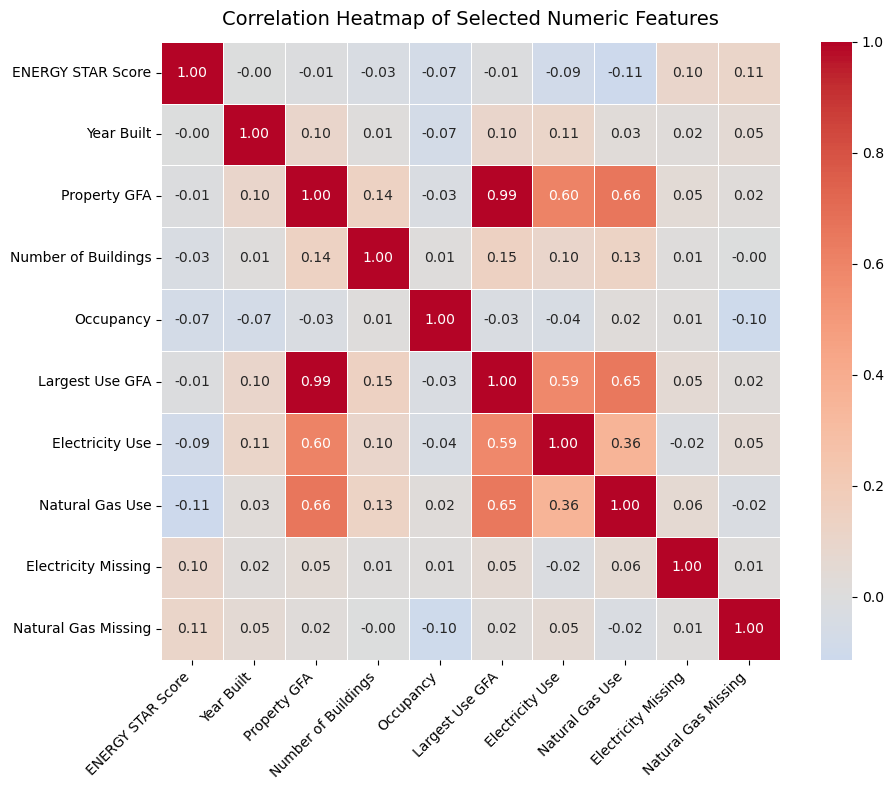

In [22]:
corr_features = [
    "ENERGY STAR Score",
    "Year Built",
    "Property GFA - Self-Reported (ft²)",
    "Number of Buildings",
    "Occupancy",
    "Largest Property Use Type - Gross Floor Area (ft²)",
    "Electricity Use - Grid Purchase (kBtu)",
    "Natural Gas Use (kBtu)",
    "Electricity_missing",
    "NaturalGas_missing"
]

corr_features = [col for col in corr_features if col in df_model.columns]

label_map = {
    "ENERGY STAR Score": "ENERGY STAR Score",
    "Year Built": "Year Built",
    "Property GFA - Self-Reported (ft²)": "Property GFA",
    "Number of Buildings": "Number of Buildings",
    "Occupancy": "Occupancy",
    "Largest Property Use Type - Gross Floor Area (ft²)": "Largest Use GFA",
    "Electricity Use - Grid Purchase (kBtu)": "Electricity Use",
    "Natural Gas Use (kBtu)": "Natural Gas Use",
    "Electricity_missing": "Electricity Missing",
    "NaturalGas_missing": "Natural Gas Missing"
}

corr_df = df_model[corr_features].corr()
corr_df = corr_df.rename(index=label_map, columns=label_map)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Correlation Heatmap of Selected Numeric Features", fontsize=14, pad=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

`Property GFA - Self-Reported (ft²)` and `Largest Property Use Type - Gross Floor Area (ft²)` were highly correlated, indicating substantial redundancy. I retained Largest Property Use Type - Gross Floor Area (ft²) because it aligns more directly with Largest Property Use Type and better reflects the size of the property’s dominant use category.

In [24]:
df_model = df_model.drop(columns=["Property GFA - Self-Reported (ft²)"], errors="ignore")

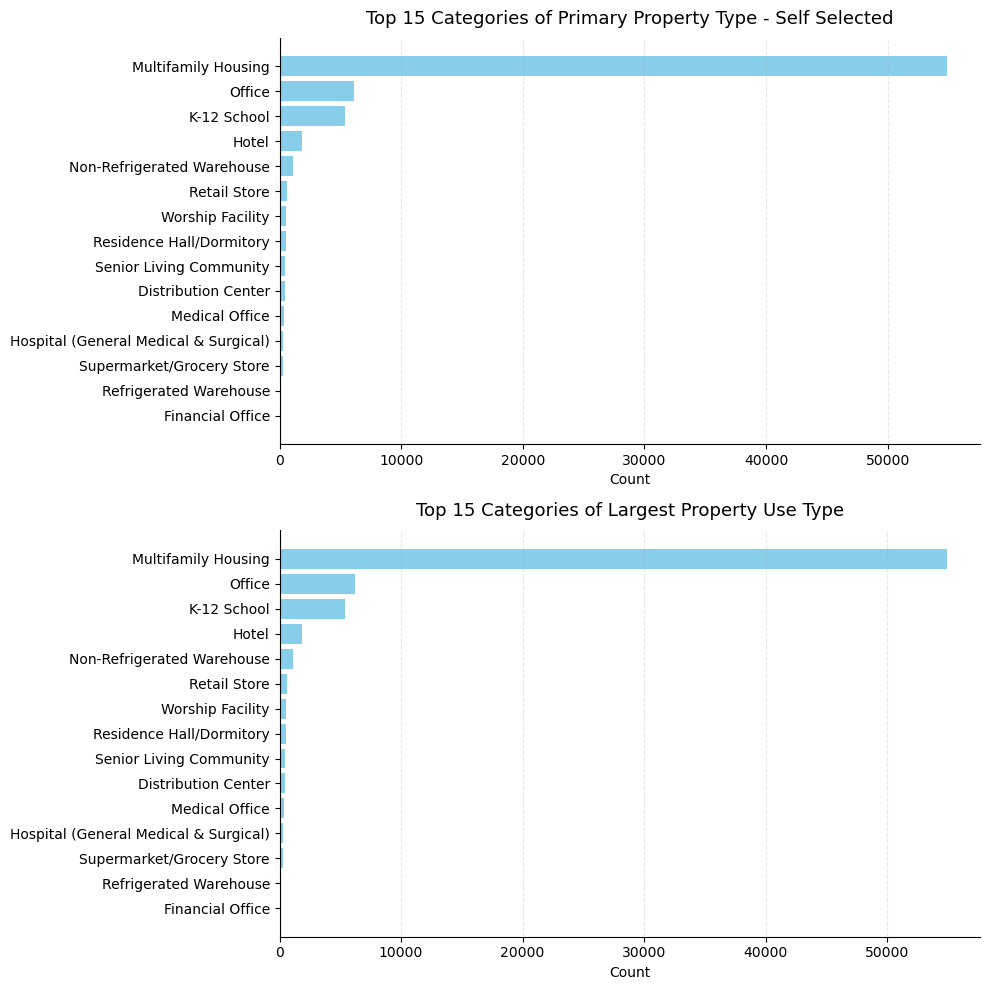

In [25]:
categorical_features_after = [
    "Primary Property Type - Self Selected",
    "Largest Property Use Type"
]

categorical_features_after = [col for col in categorical_features_after if col in df_model.columns]

top_n = 15
n_rows = len(categorical_features_after)

fig, axes = plt.subplots(n_rows, 1, figsize=(10, 5 * n_rows))

if n_rows == 1:
    axes = [axes]

for i, col in enumerate(categorical_features_after):
    count_series = df_model[col].value_counts().head(top_n).sort_values()

    axes[i].barh(count_series.index, count_series.values, color="skyblue")
    axes[i].set_title(f"Top {top_n} Categories of {col}", fontsize=13, pad=10)
    axes[i].set_xlabel("Count")
    axes[i].set_ylabel("")
    axes[i].grid(False, axis="y")
    axes[i].grid(axis="x", linestyle="--", alpha=0.3)
    axes[i].spines["top"].set_visible(False)
    axes[i].spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [26]:
df3 = df_model[["Primary Property Type - Self Selected", "Largest Property Use Type"]].copy()
same_mask = df3["Primary Property Type - Self Selected"] == df3["Largest Property Use Type"]
print("Same count:", same_mask.sum())
print("Different count:", (~same_mask).sum())
print(f"Same rate: {same_mask.mean():.2%}")
print(f"Different rate: {(~same_mask).mean():.2%}")

Same count: 73218
Different count: 159
Same rate: 99.78%
Different rate: 0.22%


`Primary Property Type - Self Selected` and `Largest Property Use Type` were nearly identical in this dataset, with 99.78% of observations having the same value in both fields. To reduce redundancy, only one of the two variables was retained. I chose `Largest Property Use Type` because it more directly reflects the dominant use category of the property by gross floor area.

In [28]:
df_model = df_model.drop(columns="Primary Property Type - Self Selected", errors="ignore")
df_model.columns

Index(['ENERGY STAR Score', 'Year Built', 'Number of Buildings', 'Occupancy',
       'Largest Property Use Type',
       'Largest Property Use Type - Gross Floor Area (ft²)',
       'Electricity Use - Grid Purchase (kBtu)', 'Natural Gas Use (kBtu)',
       'Electricity_missing', 'NaturalGas_missing'],
      dtype='object')

## 2. Preprocessing Setup

In [30]:
final_features = [
    "Year Built",
    "Number of Buildings",
    "Occupancy",
    "Largest Property Use Type",
    "Largest Property Use Type - Gross Floor Area (ft²)",
    "Electricity Use - Grid Purchase (kBtu)",
    "Natural Gas Use (kBtu)",
    "Electricity_missing",
    "NaturalGas_missing"
]
final_features = [col for col in final_features if col in df_model.columns]
X = df_model[final_features].copy()
y = df_model[target].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (73377, 9)
y shape: (73377,)


In [31]:
numeric_features_model = [
    "Year Built",
    "Number of Buildings",
    "Occupancy",
    "Largest Property Use Type - Gross Floor Area (ft²)",
    "Electricity Use - Grid Purchase (kBtu)",
    "Natural Gas Use (kBtu)",
    "Electricity_missing",
    "NaturalGas_missing"
]

numeric_features_model = [col for col in numeric_features_model if col in X.columns]
categorical_features_model = ["Largest Property Use Type"]
categorical_features_model = [col for col in categorical_features_model if col in X.columns]

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features_model),
        ("cat", categorical_transformer, categorical_features_model)
    ]
)

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['Year Built', 'Number of Buildings',
                                  'Occupancy',
                                  'Largest Property Use Type - Gross Floor '
                                  'Area (ft²)',
                                  'Electricity Use - Grid Purchase (kBtu)',
                                  'Natural Gas Use (kBtu)',
                                  'Electricity_missing',
                                  'NaturalGas_missing']),
                                ('cat',
                                 Pipeline(steps=[('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Largest Property Use Type'])])

## 3. Baseline Models

In [34]:
models = {
    "DummyRegressor": DummyRegressor(strategy="mean"),
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "RandomForestRegressor": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=2,
    ),
}

In [35]:
results = []
fitted_pipelines = {}
predictions = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2": r2_score(y_test, y_pred)
    })

    fitted_pipelines[name] = pipeline
    predictions[name] = y_pred

results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
results_df

,Model,MAE,RMSE,R2
0,RandomForestRegressor,11.605302,16.197802,0.683381
1,LinearRegression,23.015690,27.681311,0.075306
2,Ridge,23.019698,27.689488,0.074760
3,DummyRegressor,24.336083,28.791649,-0.000363


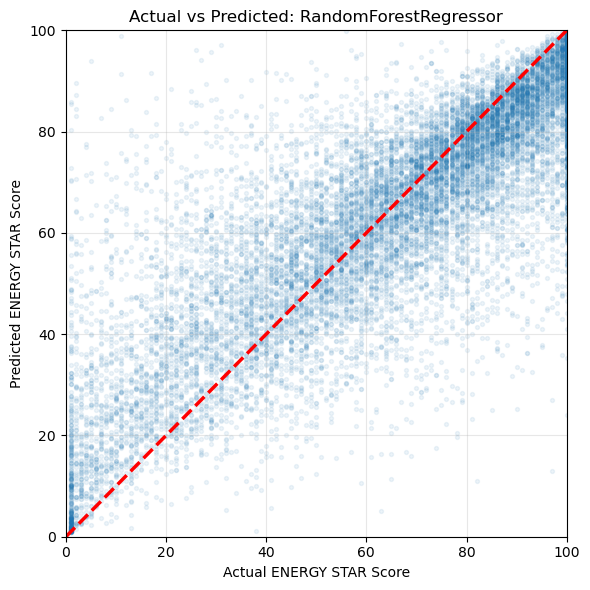

In [36]:
best_model_name = results_df.loc[0, "Model"]
best_pred = predictions[best_model_name]

plt.figure(figsize=(6, 6))
plt.scatter(y_test, best_pred, alpha=0.08, s=8)
plt.plot([0, 100], [0, 100], color="red", linewidth=2.5, linestyle="--")

plt.xlim(0, 100)
plt.ylim(0, 100)
plt.xlabel("Actual ENERGY STAR Score")
plt.ylabel("Predicted ENERGY STAR Score")
plt.title(f"Actual vs Predicted: {best_model_name}")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Current Findings

1. The selected variables seem to have real predictive value for ENERGY STAR Score.
2. Some features were redundant, so simplifying the variable set was necessary.
3. The baseline results show that nonlinear models work much better than linear ones.

## 5. Next Steps

1. The first next step is to improve feature engineering.
2. The next step is to tune the stronger models instead of only comparing default baseline versions.
3. It is also important to evaluate where the model performs well and where it still struggles.

## 6. Feature Importance

In [42]:
all_feature_effects = []

for model_name, pipeline in fitted_pipelines.items():
    preprocessor = pipeline.named_steps["preprocessor"]
    model = pipeline.named_steps["model"]
    
    feature_names = preprocessor.get_feature_names_out()
    
    if hasattr(model, "feature_importances_"):
        values = model.feature_importances_
        metric_type = "feature_importance"
        
    elif hasattr(model, "coef_"):
        values = np.ravel(model.coef_)
        metric_type = "coefficient"
        
    else:
        print(f"{model_name}: no feature importance / coefficient available")
        continue
    
    temp_df = pd.DataFrame({
        "Model": model_name,
        "Feature": feature_names,
        "Value": values,
        "Abs_Value": np.abs(values),
        "Metric_Type": metric_type
    })
    
    temp_df = temp_df.sort_values("Abs_Value", ascending=False).reset_index(drop=True)
    all_feature_effects.append(temp_df)

all_feature_effects_df = pd.concat(all_feature_effects, ignore_index=True)

DummyRegressor: no feature importance / coefficient available


In [43]:
for model_name in all_feature_effects_df["Model"].unique():
    print("=" * 80)
    print(model_name)
    display(
        all_feature_effects_df[all_feature_effects_df["Model"] == model_name]
        .sort_values("Abs_Value", ascending=False)
        .reset_index(drop=True)
    )

LinearRegression


,Model,Feature,Value,Abs_Value,Metric_Type
0,LinearRegression,cat__Largest Property Use Type_Data Center,121.088214,121.088214,coefficient
1,LinearRegression,cat__Largest Property Use Type_Wastewater Trea...,71.624864,71.624864,coefficient
2,LinearRegression,cat__Largest Property Use Type_Single-Family Home,-54.765453,54.765453,coefficient
3,LinearRegression,cat__Largest Property Use Type_Hospital (Gener...,34.755795,34.755795,coefficient
4,LinearRegression,cat__Largest Property Use Type_Worship Facility,-29.524853,29.524853,coefficient
5,LinearRegression,cat__Largest Property Use Type_Distribution Ce...,-20.920278,20.920278,coefficient
6,LinearRegression,cat__Largest Property Use Type_Refrigerated Wa...,-20.748892,20.748892,coefficient
7,LinearRegression,cat__Largest Property Use Type_Hotel,-20.321295,20.321295,coefficient
8,LinearRegression,cat__Largest Property Use Type_Non-Refrigerate...,-17.827236,17.827236,coefficient
9,LinearRegression,cat__Largest Property Use Type_Wholesale Club/...,-16.982358,16.982358,coefficient


Ridge


,Model,Feature,Value,Abs_Value,Metric_Type
0,Ridge,cat__Largest Property Use Type_Data Center,80.414585,80.414585,coefficient
1,Ridge,cat__Largest Property Use Type_Wastewater Trea...,69.651268,69.651268,coefficient
2,Ridge,cat__Largest Property Use Type_Single-Family Home,-45.729211,45.729211,coefficient
3,Ridge,cat__Largest Property Use Type_Hospital (Gener...,35.824701,35.824701,coefficient
4,Ridge,cat__Largest Property Use Type_Worship Facility,-27.756941,27.756941,coefficient
5,Ridge,cat__Largest Property Use Type_Distribution Ce...,-19.172298,19.172298,coefficient
6,Ridge,cat__Largest Property Use Type_Refrigerated Wa...,-18.866449,18.866449,coefficient
7,Ridge,cat__Largest Property Use Type_Hotel,-18.655101,18.655101,coefficient
8,Ridge,cat__Largest Property Use Type_Non-Refrigerate...,-16.140239,16.140239,coefficient
9,Ridge,cat__Largest Property Use Type_Financial Office,15.457874,15.457874,coefficient


RandomForestRegressor


,Model,Feature,Value,Abs_Value,Metric_Type
0,RandomForestRegressor,num__Natural Gas Use (kBtu),0.301218,0.301218,feature_importance
1,RandomForestRegressor,num__Largest Property Use Type - Gross Floor A...,0.295507,0.295507,feature_importance
2,RandomForestRegressor,num__Electricity Use - Grid Purchase (kBtu),0.227234,0.227234,feature_importance
3,RandomForestRegressor,num__Year Built,0.079531,0.079531,feature_importance
4,RandomForestRegressor,cat__Largest Property Use Type_Office,0.014426,0.014426,feature_importance
5,RandomForestRegressor,num__NaturalGas_missing,0.013751,0.013751,feature_importance
6,RandomForestRegressor,cat__Largest Property Use Type_Multifamily Hou...,0.012243,0.012243,feature_importance
7,RandomForestRegressor,num__Occupancy,0.009819,0.009819,feature_importance
8,RandomForestRegressor,num__Electricity_missing,0.008278,0.008278,feature_importance
9,RandomForestRegressor,cat__Largest Property Use Type_Non-Refrigerate...,0.006100,0.006100,feature_importance


Overall, the feature-importance analysis suggests that the model is driven mainly by **energy-use and size-related variables**. In the linear and ridge models, property-type categories account for many of the largest coefficients, while electricity use, natural gas use, and floor area are the most important numeric predictors. In the random forest model, the signal becomes even clearer: natural gas use, largest property use floor area, and electricity use dominate prediction, followed by year built, with the remaining features contributing more modestly. This indicates that the most useful information comes from direct measures of building size and energy consumption, while property type, missingness, occupancy, and building count add smaller supporting effects.

## 7. Hyperparameter Tuning for the Random Forest Model

Since the random forest model performed best in the earlier baseline comparison, the next step is to tune its hyperparameters rather than continue improving weaker models.

In this section, I use `RandomizedSearchCV` to search over a practical range of random forest settings. I then compare the tuned model with the original baseline random forest and visualize the tuned model's predictions against the true ENERGY STAR Score values.

In [47]:
baseline_rf = results_df[results_df["Model"] == "RandomForestRegressor"].copy()
baseline_rf

,Model,MAE,RMSE,R2
0,RandomForestRegressor,11.605302,16.197802,0.683381


In [48]:
rf_tuning_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

In [49]:
param_distributions = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", "log2"]
}

In [50]:
random_search = RandomizedSearchCV(
    estimator=rf_tuning_pipeline,
    param_distributions=param_distributions,
    n_iter= 5,
    scoring="neg_root_mean_squared_error",
    cv= 3,
    random_state=42,
    n_jobs=1,
    verbose=1
)

random_search.fit(X_train, y_train)

Fitting 3 folds for each of 5 candidates, totalling 15 fits


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Year '
                                                                                'Built',
                                                                                'Number '
                                                                                'of '
                                                                                'Buildings',
                                                                                'Occupancy',
                                                                                'Largest '
                                                                                'Property '
                                                                                'Use '
                                                                                'Type '
                                                                                '- '
                                                                                'Gross '
                                                                                'Floor '
                                                                                'Area '
                                                                                '(ft²)',
                                                                                'Electricity '
                                                                                'Use '
                                                                                '- '
                                                                                'Grid '
                                                                                'Purchase '
                                                                                '(kBtu)',
                                                                                'Natural '
                                                                                'Gas '
                                                                                'Use '
                                                                                '(kBtu)',
                                                                                'Electricity_...
                                                                                'Property '
                                                                                'Use '
                                                                                'Type'])])),
                                             ('model',
                                              RandomForestRegressor(random_state=42))]),
                   n_iter=5, n_jobs=1,
                   param_distributions={'model__max_depth': [None, 10, 20],
                                        'model__max_features': ['sqrt', 'log2'],
                                        'model__min_samples_leaf': [1, 2],
                                        'model__min_samples_split': [2, 5],
                                        'model__n_estimators': [100, 200, 300]},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=1)

In [51]:
print("Best parameters:")
print(random_search.best_params_)

Best parameters:
{'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': None}


In [52]:
best_rf_tuned = random_search.best_estimator_
y_pred_tuned = best_rf_tuned.predict(X_test)

tuned_mae = mean_absolute_error(y_test, y_pred_tuned)
tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
tuned_r2 = r2_score(y_test, y_pred_tuned)

print("Tuned Random Forest Performance")
print("MAE:", round(tuned_mae, 4))
print("RMSE:", round(tuned_rmse, 4))
print("R2:", round(tuned_r2, 4))

Tuned Random Forest Performance
MAE: 11.2572
RMSE: 15.3842
R2: 0.7144


In [53]:
baseline_rf_metrics = results_df[results_df["Model"] == "RandomForestRegressor"].iloc[0]

rf_comparison_df = pd.DataFrame([
    {
        "Version": "Baseline Random Forest",
        "MAE": baseline_rf_metrics["MAE"],
        "RMSE": baseline_rf_metrics["RMSE"],
        "R2": baseline_rf_metrics["R2"]
    },
    {
        "Version": "Tuned Random Forest",
        "MAE": tuned_mae,
        "RMSE": tuned_rmse,
        "R2": tuned_r2
    }
])

rf_comparison_df

,Version,MAE,RMSE,R2
0,Baseline Random Forest,11.605302,16.197802,0.683381
1,Tuned Random Forest,11.257199,15.384206,0.714389


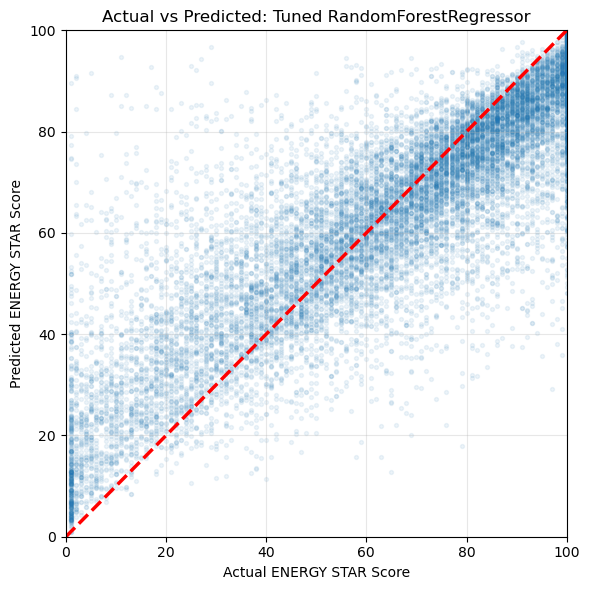

In [54]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_tuned, alpha=0.08, s=8)
plt.plot([0, 100], [0, 100], color="red", linewidth=2.5, linestyle="--")

plt.xlim(0, 100)
plt.ylim(0, 100)
plt.xlabel("Actual ENERGY STAR Score")
plt.ylabel("Predicted ENERGY STAR Score")
plt.title(f"Actual vs Predicted: Tuned RandomForestRegressor")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

After tuning the random forest, the next step is not to add more models, but to understand where the tuned model still makes errors. Therefore, I extend the analysis by examining residual patterns, prediction error across score ranges, and variation in error across property types.

### Save the final tuned model for quick demo

The final tuned random forest pipeline is saved and reloaded here for a quick demonstration check.


In [57]:
import joblib
from pathlib import Path

model_path = "ying_tuned_rf_pipeline.pkl"
joblib.dump(best_rf_tuned, model_path, compress=3)

demo_model = joblib.load(model_path)
demo_pred = demo_model.predict(X_test.iloc[[0]].copy())[0]
size_mb = Path(model_path).stat().st_size / (1024 * 1024)

print("Reload success:", type(demo_model))
print(f"File size: {size_mb:.2f} MB")
print(f"Demo prediction: {demo_pred:.2f}")
print(f"Actual value: {y_test.iloc[0]:.2f}")


Reload success: <class 'sklearn.pipeline.Pipeline'>
File size: 86.22 MB
Demo prediction: 78.94
Actual value: 22.00


## 8. Further Analysis for the Tuned Random Forest Model

Residual summary:


,residual,abs_error
count,14676.000000,14676.000000
mean,0.175023,11.257199
std,15.383735,10.486027
min,-89.020000,0.000000
25%,-7.580000,3.760000
50%,1.595000,8.250000
75%,8.740000,15.370000
max,67.910000,89.020000


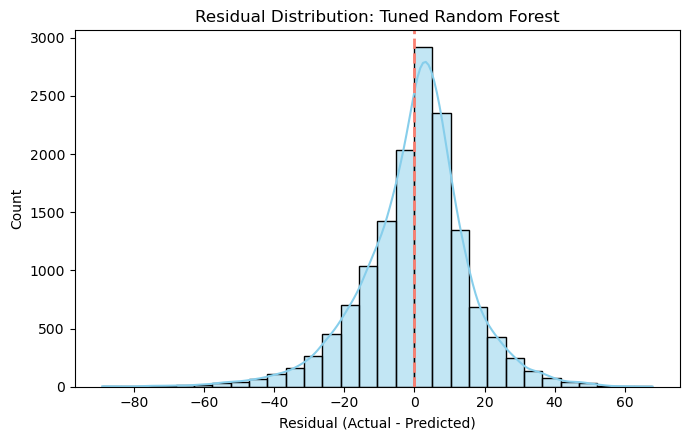

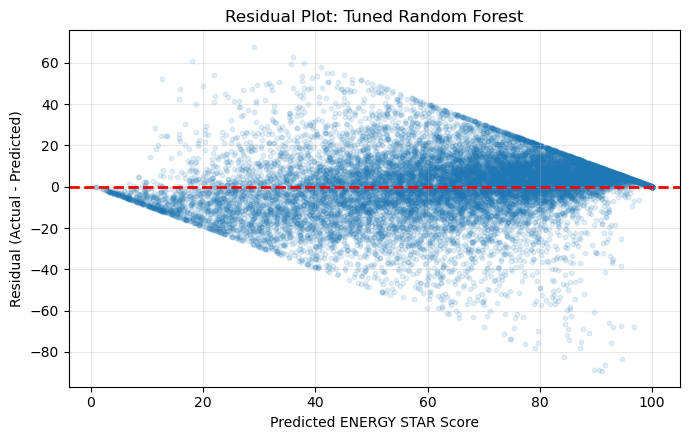

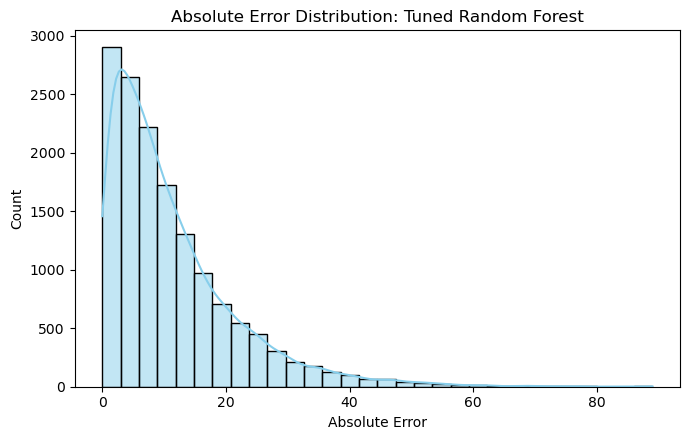

In [59]:
# Residual analysis for the tuned random forest

tuned_eval_df = pd.DataFrame({
    "actual": np.array(y_test),
    "predicted": np.array(y_pred_tuned)
})

tuned_eval_df["residual"] = tuned_eval_df["actual"] - tuned_eval_df["predicted"]
tuned_eval_df["abs_error"] = tuned_eval_df["residual"].abs()

print("Residual summary:")
display(tuned_eval_df[["residual", "abs_error"]].describe())

# Residual distribution
plt.figure(figsize=(7, 4.5))
sns.histplot(tuned_eval_df["residual"], bins=30, kde=True, color="skyblue")
plt.axvline(0, color="salmon", linestyle="--", linewidth=2)
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Count")
plt.title("Residual Distribution: Tuned Random Forest")
plt.tight_layout()
plt.show()

# Residuals vs predicted
plt.figure(figsize=(7, 4.5))
plt.scatter(tuned_eval_df["predicted"], tuned_eval_df["residual"], alpha=0.12, s=10)
plt.axhline(0, color="red", linestyle="--", linewidth=2)
plt.xlabel("Predicted ENERGY STAR Score")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot: Tuned Random Forest")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Absolute error distribution
plt.figure(figsize=(7, 4.5))
sns.histplot(tuned_eval_df["abs_error"], bins=30, kde=True, color="skyblue")
plt.xlabel("Absolute Error")
plt.ylabel("Count")
plt.title("Absolute Error Distribution: Tuned Random Forest")
plt.tight_layout()
plt.show()

### Residual Analysis

The residual distribution is centered close to zero, which suggests that the tuned random forest does not show a strong overall bias toward systematic overprediction or underprediction. Most residuals are concentrated near zero, indicating that the model makes reasonably accurate predictions for a large share of observations.

However, the residual histogram is not perfectly symmetric. The negative tail appears somewhat longer than the positive tail, which suggests that the model makes some relatively large overpredictions for a subset of buildings. In other words, there are cases where the predicted ENERGY STAR Score is noticeably higher than the true score.

The residual-versus-predicted plot also shows a clear triangular pattern. This is expected to some extent because the target variable is bounded between 0 and 100, which naturally limits the possible residual range at very low and very high predicted values. At the same time, the plot suggests that prediction errors are not completely uniform across the score range. The spread of residuals is larger in the middle and upper-middle prediction ranges, indicating that the model is less stable for some buildings in those regions.

Finally, the absolute error distribution is strongly right-skewed. This means that most test cases have relatively small prediction errors, while a smaller number of observations account for much larger errors. Overall, the tuned random forest performs well for the majority of buildings, but there is still room for improvement on harder-to-predict cases, especially those associated with larger residual magnitudes.

In [61]:
# Prediction error by score band

tuned_eval_df["score_band"] = pd.cut(
    tuned_eval_df["actual"],
    bins=[0, 25, 50, 75, 100],
    labels=["1-25", "26-50", "51-75", "76-100"],
    include_lowest=True
)

score_band_summary = (
    tuned_eval_df.groupby("score_band", observed=False)
    .agg(
        Count=("actual", "size"),
        Mean_Actual=("actual", "mean"),
        Mean_Predicted=("predicted", "mean"),
        MAE=("abs_error", "mean"),
        Median_AE=("abs_error", "median"),
        RMSE=("residual", lambda x: np.sqrt(np.mean(x**2)))
    )
    .reset_index()
)

score_band_summary

,score_band,Count,Mean_Actual,Mean_Predicted,MAE,Median_AE,RMSE
0,1-25,2092,11.856119,29.970598,18.300181,15.095,23.329937
1,26-50,2548,39.008634,48.076447,12.260384,9.510,16.094402
2,51-75,3965,63.792434,62.788967,8.248571,6.370,10.960597
3,76-100,6071,89.821446,80.005901,10.374179,7.670,14.050035


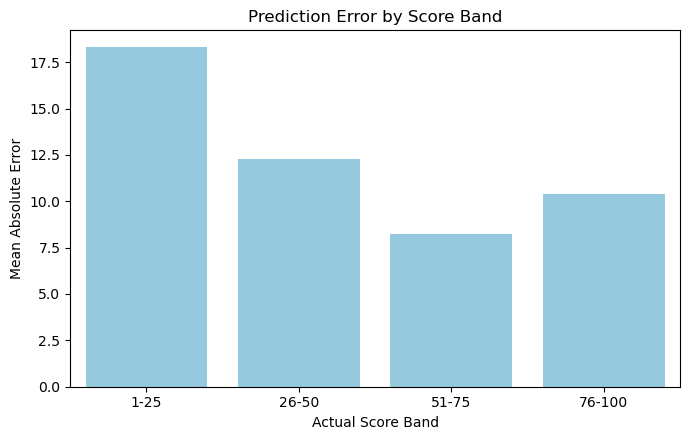

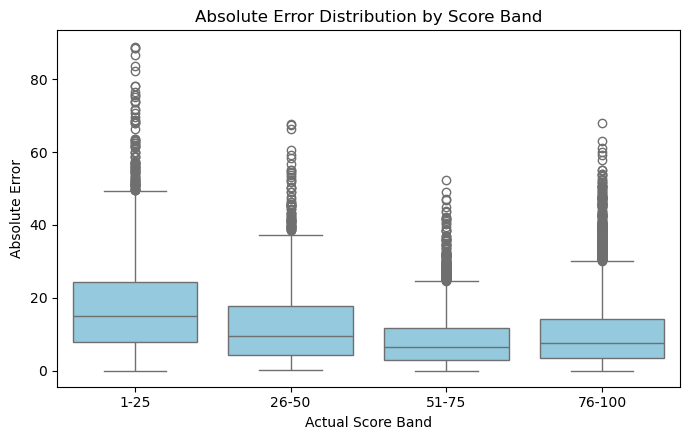

In [62]:
# Visualization for score-band error

plt.figure(figsize=(7, 4.5))
sns.barplot(data=score_band_summary, x="score_band", y="MAE", color="skyblue")
plt.xlabel("Actual Score Band")
plt.ylabel("Mean Absolute Error")
plt.title("Prediction Error by Score Band")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4.5))
sns.boxplot(data=tuned_eval_df, x="score_band", y="abs_error", color="skyblue")
plt.xlabel("Actual Score Band")
plt.ylabel("Absolute Error")
plt.title("Absolute Error Distribution by Score Band")
plt.tight_layout()
plt.show()

### Prediction Error by Score Band

The score-band analysis shows that the tuned random forest does not perform equally well across the full ENERGY STAR Score range. The largest mean absolute error appears in the lowest score band (1-25), indicating that the model has the most difficulty predicting poorly performing buildings.

In contrast, the model performs best in the middle score range, especially for buildings with actual scores between 51 and 75, where the mean absolute error is the lowest. This suggests that the model captures the patterns of mid-range buildings more effectively than those at the extremes.

The error increases again in the highest score band (76-100), although it remains lower than in the 1-25 range. This may indicate that very high-scoring buildings are also somewhat harder to predict, possibly because of ceiling effects near the upper bound of the target variable.

The boxplot further shows that all score bands contain outliers, but the lowest score band has both a higher median absolute error and a wider spread of errors. Overall, these results suggest that the tuned model is most reliable in the middle score ranges and less accurate for buildings at the lower and upper ends of the score distribution.

In [64]:
# Prediction error by property type

property_type_col = "Largest Property Use Type"

property_error_df = X_test[[property_type_col]].copy().reset_index(drop=True)
property_error_df["actual"] = np.array(y_test)
property_error_df["predicted"] = np.array(y_pred_tuned)
property_error_df["residual"] = property_error_df["actual"] - property_error_df["predicted"]
property_error_df["abs_error"] = property_error_df["residual"].abs()

property_type_summary = (
    property_error_df.groupby(property_type_col)
    .agg(
        Count=("actual", "size"),
        Mean_Actual=("actual", "mean"),
        Mean_Predicted=("predicted", "mean"),
        MAE=("abs_error", "mean"),
        Median_AE=("abs_error", "median"),
        RMSE=("residual", lambda x: np.sqrt(np.mean(x**2)))
    )
    .sort_values(["MAE", "Count"], ascending=[False, False])
    .reset_index()
)

property_type_summary.head(15)

,Largest Property Use Type,Count,Mean_Actual,Mean_Predicted,MAE,Median_AE,RMSE
0,Data Center,1,100.000000,78.870000,21.130000,21.130,21.130000
1,Medical Office,63,71.126984,61.760212,17.134074,14.190,21.583667
2,Hospital (General Medical & Surgical),64,69.828125,61.630000,15.945937,14.015,18.931960
3,Senior Living Community,90,56.411111,53.221778,15.246667,12.135,19.024459
4,Hotel,363,52.774105,51.070380,14.403416,12.380,17.901970
5,Wholesale Club/Supercenter,13,56.384615,50.669615,14.320385,14.530,15.555508
6,Bank Branch,4,87.750000,74.275000,13.475000,12.725,14.999145
7,Supermarket/Grocery Store,41,60.463415,57.790532,13.347377,9.180,17.266807
8,Worship Facility,81,42.938272,45.780593,12.699111,12.060,15.576837
9,Vehicle Dealership,18,62.000000,62.597917,12.582083,8.880,15.941364


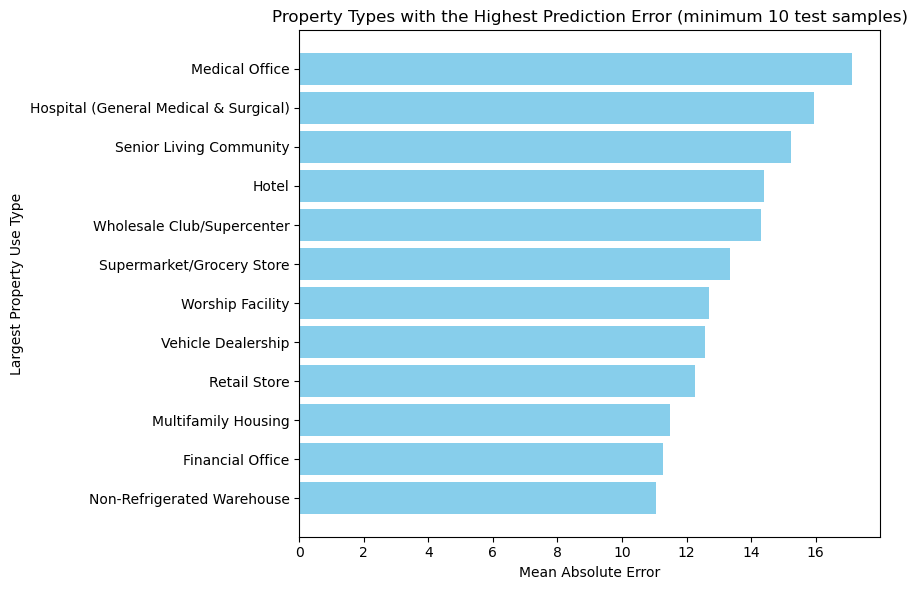

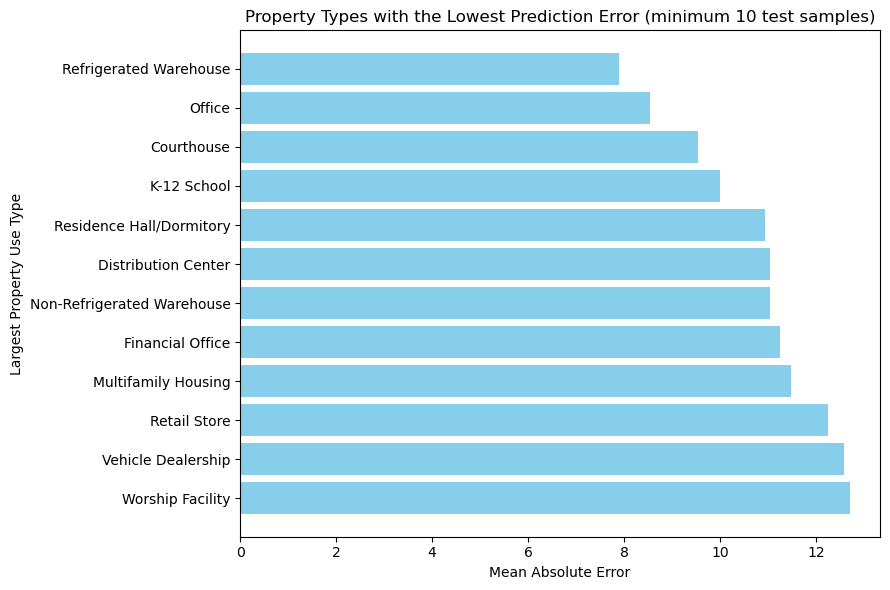

In [65]:
# Focus on property types with a reasonable number of test samples
property_type_summary_filtered = property_type_summary[property_type_summary["Count"] >= 10].copy()

top_property_mae = (
    property_type_summary_filtered
    .sort_values("MAE", ascending=False)
    .head(12)
    .sort_values("MAE", ascending=True)
)

plt.figure(figsize=(9, 6))
plt.barh(top_property_mae[property_type_col], top_property_mae["MAE"], color="skyblue")
plt.xlabel("Mean Absolute Error")
plt.ylabel("Largest Property Use Type")
plt.title("Property Types with the Highest Prediction Error (minimum 10 test samples)")
plt.tight_layout()
plt.show()

# Optional: best-predicted property types
best_property_mae = (
    property_type_summary_filtered
    .sort_values("MAE", ascending=True)
    .head(12)
    .sort_values("MAE", ascending=False)
)

plt.figure(figsize=(9, 6))
plt.barh(best_property_mae[property_type_col], best_property_mae["MAE"], color="skyblue")
plt.xlabel("Mean Absolute Error")
plt.ylabel("Largest Property Use Type")
plt.title("Property Types with the Lowest Prediction Error (minimum 10 test samples)")
plt.tight_layout()
plt.show()

### Prediction Error by Property Type

The property-type analysis shows that the tuned random forest does not perform equally well across all building categories. Some property types have noticeably higher mean absolute error than others, which suggests that prediction difficulty varies by building use.

Among the property types with at least 10 test samples, the model performs worst for categories such as **Medical Office**, **Hospital (General Medical & Surgical)**, **Senior Living Community**, and **Hotel**. These categories likely have more complex or heterogeneous energy-use patterns, making them harder for the model to predict accurately.

In contrast, the model performs best for categories such as **Refrigerated Warehouse**, **Office**, **Courthouse**, and **K-12 School**, which have lower mean absolute error. This suggests that the relationship between the input features and ENERGY STAR Score is more stable or easier for the model to learn in these property types.

The comparison also shows that some categories, such as **Retail Store**, **Vehicle Dealership**, **Worship Facility**, **Multifamily Housing**, and **Financial Office**, appear in both the higher-error and lower-error plots. This means their performance is relatively middle-range: they are neither the hardest nor the easiest property types to predict.

Overall, these results suggest that property type remains an important source of variation in model accuracy. Even though the tuned random forest performs well overall, it is less reliable for certain building categories, especially healthcare-related and hospitality-related properties. This indicates that future improvement may come from adding more property-type-specific features or from modeling certain building categories separately.

In [67]:
# Tuned vs baseline random forest comparison summary

baseline_rf_pipeline = fitted_pipelines["RandomForestRegressor"]
y_pred_baseline_rf = baseline_rf_pipeline.predict(X_test)

comparison_eval_df = pd.DataFrame({
    "actual": np.array(y_test),
    "baseline_pred": np.array(y_pred_baseline_rf),
    "tuned_pred": np.array(y_pred_tuned)
})

comparison_eval_df["baseline_abs_error"] = (comparison_eval_df["actual"] - comparison_eval_df["baseline_pred"]).abs()
comparison_eval_df["tuned_abs_error"] = (comparison_eval_df["actual"] - comparison_eval_df["tuned_pred"]).abs()
comparison_eval_df["error_improvement"] = comparison_eval_df["baseline_abs_error"] - comparison_eval_df["tuned_abs_error"]

summary_comparison = pd.DataFrame([
    {
        "Model": "Baseline Random Forest",
        "MAE": mean_absolute_error(y_test, y_pred_baseline_rf),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_baseline_rf)),
        "R2": r2_score(y_test, y_pred_baseline_rf)
    },
    {
        "Model": "Tuned Random Forest",
        "MAE": mean_absolute_error(y_test, y_pred_tuned),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_tuned)),
        "R2": r2_score(y_test, y_pred_tuned)
    }
])

summary_comparison

,Model,MAE,RMSE,R2
0,Baseline Random Forest,11.605302,16.197802,0.683381
1,Tuned Random Forest,11.257199,15.384206,0.714389


In [68]:
# Differences and simple interpretation

baseline_row = summary_comparison.iloc[0]
tuned_row = summary_comparison.iloc[1]

print("Metric changes (Tuned - Baseline):")
print("MAE change: ", round(tuned_row["MAE"] - baseline_row["MAE"], 4))
print("RMSE change:", round(tuned_row["RMSE"] - baseline_row["RMSE"], 4))
print("R2 change:  ", round(tuned_row["R2"] - baseline_row["R2"], 4))

print("\nSample-level comparison:")
print("Tuned model better on", (comparison_eval_df["error_improvement"] > 0).sum(), "test cases")
print("Baseline model better on", (comparison_eval_df["error_improvement"] < 0).sum(), "test cases")
print("Tie on", (comparison_eval_df["error_improvement"] == 0).sum(), "test cases")

Metric changes (Tuned - Baseline):
MAE change:  -0.3481
RMSE change: -0.8136
R2 change:   0.031

Sample-level comparison:
Tuned model better on 7579 test cases
Baseline model better on 7093 test cases
Tie on 4 test cases


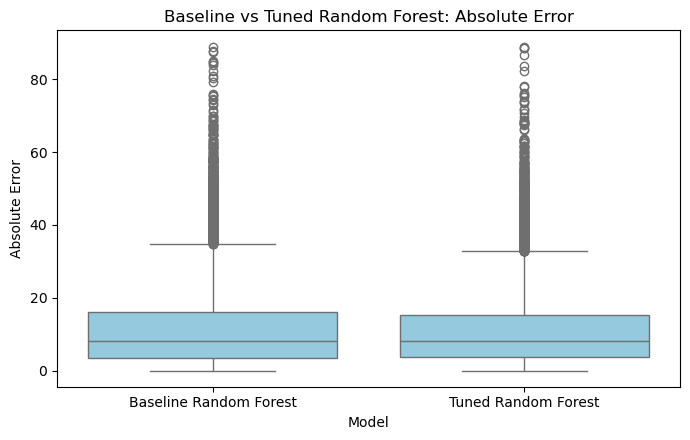

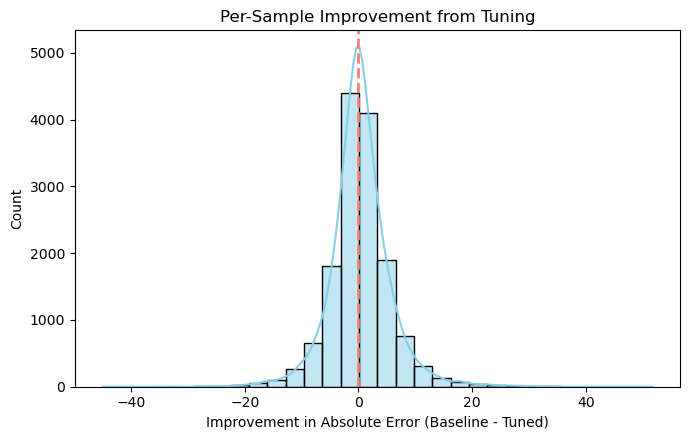

In [69]:
# Visual comparison of absolute errors

comparison_long_df = pd.DataFrame({
    "Model": ["Baseline Random Forest"] * len(comparison_eval_df) + ["Tuned Random Forest"] * len(comparison_eval_df),
    "Absolute Error": pd.concat([
        comparison_eval_df["baseline_abs_error"],
        comparison_eval_df["tuned_abs_error"]
    ], ignore_index=True)
})

plt.figure(figsize=(7, 4.5))
sns.boxplot(data=comparison_long_df, x="Model", y="Absolute Error", color="skyblue")
plt.title("Baseline vs Tuned Random Forest: Absolute Error")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4.5))
sns.histplot(comparison_eval_df["error_improvement"], bins=30, kde=True, color="skyblue")
plt.axvline(0, color="salmon", linestyle="--", linewidth=2)
plt.xlabel("Improvement in Absolute Error (Baseline - Tuned)")
plt.ylabel("Count")
plt.title("Per-Sample Improvement from Tuning")
plt.tight_layout()
plt.show()

### Tuned vs. Baseline Random Forest Comparison

The tuned random forest shows a modest but consistent improvement over the baseline random forest. After tuning, **MAE decreases by 0.3481**, **RMSE decreases by 0.8136**, and **R² increases by 0.031**. Because lower MAE and RMSE indicate smaller prediction error and higher R² indicates better explanatory performance, these results suggest that hyperparameter tuning improves the overall predictive quality of the model.

The sample-level comparison supports the same conclusion. The tuned model produces smaller absolute error for **7,579** test cases, while the baseline model performs better for **7,093** cases, with only **4 ties**. This means the improvement is not driven by only a few extreme observations; rather, the tuned model performs better on slightly more individual buildings across the test set.

The boxplot comparison shows that the two models have broadly similar error distributions, but the tuned random forest has a slightly lower overall error profile. This suggests that tuning does not completely change model behavior, but it does provide a meaningful refinement over the baseline.

The distribution of per-sample improvement is centered close to zero, which indicates that for many observations the difference between the two models is relatively small. However, the distribution is shifted slightly toward positive values, showing that the tuned model more often reduces error than increases it. In other words, hyperparameter tuning leads to a moderate overall gain rather than a dramatic change.

Overall, these results suggest that the baseline random forest was already strong, and tuning provided an incremental but worthwhile improvement. The tuned model is therefore the better final choice because it achieves slightly better aggregate metrics and performs better on more individual test cases.

## 9. Summary

This project developed a predictive modeling workflow for **ENERGY STAR Score** using building characteristics, energy-use variables, and property-type information. The analysis began with exploratory data analysis and preprocessing, followed by baseline model comparison, feature interpretation, model tuning, and error analysis.

Among the baseline models, **RandomForestRegressor** clearly outperformed the linear models, showing that the relationship between the predictors and ENERGY STAR Score is not purely linear. Feature-effect analysis further showed that the most important predictors were primarily **natural gas use**, **largest property use floor area**, and **electricity use**, while variables such as **year built**, **missingness indicators**, and **property type** provided additional but smaller predictive value.

After hyperparameter tuning, the random forest achieved a modest but meaningful improvement over the baseline version. Both **MAE** and **RMSE** decreased, while **R²** increased, indicating that tuning improved the overall predictive quality of the model. Although the improvement was not dramatic, it was consistent enough to justify selecting the tuned random forest as the final model.

The error analysis provided additional insight into model behavior. Residuals were centered near zero overall, suggesting no strong global prediction bias, but the model still made larger errors for a subset of buildings. Prediction accuracy also varied across score bands: the model performed best in the middle range and less accurately for buildings at the lower and upper ends of the score distribution. In addition, prediction error differed across property types, with some categories such as **Medical Office**, **Hospital**, **Senior Living Community**, and **Hotel** proving harder to predict than others.

Overall, the final results suggest that the tuned random forest is an effective model for this task, especially because it captures nonlinear relationships more successfully than the linear baselines. At the same time, the remaining error patterns indicate that future improvements may come from adding more building-specific features, incorporating stronger measures of building efficiency, or developing more specialized models for difficult property categories.